<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (4600, 18)
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renova

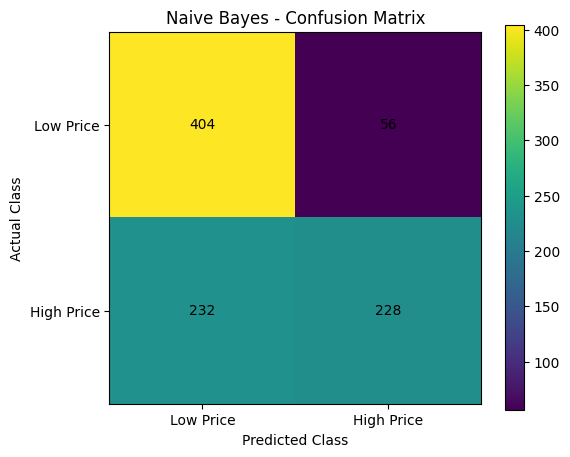

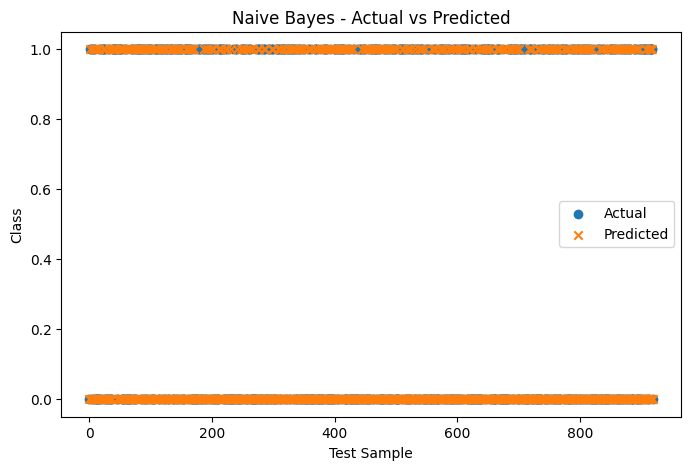

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ==========================================
# 2. CREATE CLASS
# ==========================================

# Median price is used as the classification threshold
median_price = df["price"].median()

df["Class"] = (df["price"] >= median_price).astype(int)

print("\nMedian Price:", median_price)

print("\nClass Distribution:")
print(df["Class"].value_counts())


# ==========================================
# 3. SELECT FEATURES
# ==========================================

features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

X = df[features]
y = df["Class"]


# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 5. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 6. CREATE NAIVE BAYES MODEL
# ==========================================

model = GaussianNB()


# ==========================================
# 7. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)


# ==========================================
# 8. PREDICTION
# ==========================================

y_pred = model.predict(X_test)

# Probability for Class 1
y_prob = model.predict_proba(X_test)[:, 1]


# ==========================================
# 9. EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n======================================")
print("NAIVE BAYES RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ==========================================
# 10. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 11. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


# ==========================================
# 12. CONFUSION MATRIX GRAPH
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Low Price", "High Price"])
plt.yticks([0, 1], ["Low Price", "High Price"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()


# ==========================================
# 13. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual"
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    marker="x"
)

plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Naive Bayes - Actual vs Predicted")
plt.legend()

plt.show()